# Transfer Market Valuation Forecaster — Presentation-Ready Analysis
### Predicting player market values for roster planning and transfer-window negotiations

**Course:** OPIM 5671  
**Purpose of this notebook:** A streamlined, reproducible version of the full team analysis. It keeps the decisions, evidence, models, charts, and prototype outputs needed for the final presentation while removing duplicate exploratory paths.

> **Important:** The target is **Transfermarkt market value**, not the fee a club will actually pay.

## 1. Setup and data
**Story for the slides:** We use historical Transfermarkt valuation events, convert them to a regular quarterly panel, and forecast future market value for a curated cohort of players with sufficiently long histories.

In [1]:
# Colab-first setup: install missing packages and download the public Kaggle dataset
import os, sys, subprocess, importlib.util, warnings

# Force KaggleHub to use a normal Colab cache instead of a /kaggle/input path
if os.path.isdir("/content"):
    os.environ["KAGGLEHUB_CACHE"] = "/content/kagglehub_cache"

for pkg in ["kagglehub", "statsmodels"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import kagglehub
from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.formula.api as smf
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.max_colwidth", 120)

DATASET = "kanchana1990/football-transfer-value-intelligence-2024"
path = kagglehub.dataset_download(DATASET, force_download=False)
print("Dataset download/cache location:", path)


100%|██████████| 186k/186k [00:00<00:00, 350kB/s]

Extracting files...
Dataset download/cache location: /content/kagglehub_cache/datasets/kanchana1990/football-transfer-value-intelligence-2024/versions/1


In [2]:
# Find and load the CSV files recursively (robust to KaggleHub folder-layout changes)
search_roots = [path]
if os.path.isdir("/content/kagglehub_cache"):
    search_roots.append("/content/kagglehub_cache")

csv_paths = {}
for root0 in search_roots:
    if not root0 or not os.path.exists(root0):
        continue
    for root, _, files in os.walk(root0):
        for f in files:
            if f.lower().endswith(".csv"):
                csv_paths.setdefault(f, os.path.join(root, f))

required = ["transfermarkt_value_history.csv", "transfermarkt_player_values.csv"]
missing = [f for f in required if f not in csv_paths]
if missing:
    raise FileNotFoundError(
        "Dataset downloaded, but required CSV file(s) were not found: " + ", ".join(missing) +
        "\nFound CSV files: " + (", ".join(sorted(csv_paths)) if csv_paths else "none")
    )

print("CSV files found:")
for f in sorted(csv_paths):
    print(" -", f, "->", csv_paths[f])

hist = pd.read_csv(csv_paths["transfermarkt_value_history.csv"])
players = pd.read_csv(csv_paths["transfermarkt_player_values.csv"])

# Validate the columns used by the streamlined pipeline before doing any modeling
required_hist_cols = {"player_id", "valuation_date", "value_eur", "age_at_date"}
required_player_cols = {"player_id", "name", "league_name", "position_group", "current_club"}
missing_hist = sorted(required_hist_cols - set(hist.columns))
missing_players = sorted(required_player_cols - set(players.columns))
if missing_hist or missing_players:
    raise ValueError(f"Unexpected dataset schema. Missing history columns={missing_hist}; player columns={missing_players}")

hist["valuation_date"] = pd.to_datetime(hist["valuation_date"], format="%d/%m/%Y")
hist = hist.sort_values(["player_id", "valuation_date"]).reset_index(drop=True)
hist["value_m"] = hist["value_eur"] / 1e6
hist["q_idx"] = hist["valuation_date"].dt.year * 4 + hist["valuation_date"].dt.quarter

hist_q = hist.groupby(["player_id", "q_idx"])["value_m"].last().reset_index()
coverage = hist_q.groupby("player_id")["q_idx"].agg(first_q="min", last_q="max", observed_q="nunique")
coverage["span_q"] = coverage["last_q"] - coverage["first_q"] + 1
coverage["filled_q"] = coverage["span_q"] - coverage["observed_q"]
coverage["real_share"] = coverage["observed_q"] / coverage["span_q"]

summary = pd.Series({
    "Valuation events": len(hist),
    "Players in history": hist["player_id"].nunique(),
    "First valuation": hist["valuation_date"].min().date(),
    "Latest valuation": hist["valuation_date"].max().date(),
    "Median market value (€M)": round(hist["value_m"].median(), 1),
    "Maximum market value (€M)": round(hist["value_m"].max(), 1),
}, name="Value").to_frame()
display(summary)


CSV files found:
 - data_dictionary.csv -> /content/kagglehub_cache/datasets/kanchana1990/football-transfer-value-intelligence-2024/versions/1/Football_Player_Market_Value_Trajectories/data_dictionary.csv
 - transfermarkt_player_values.csv -> /content/kagglehub_cache/datasets/kanchana1990/football-transfer-value-intelligence-2024/versions/1/Football_Player_Market_Value_Trajectories/transfermarkt_player_values.csv
 - transfermarkt_value_history.csv -> /content/kagglehub_cache/datasets/kanchana1990/football-transfer-value-intelligence-2024/versions/1/Football_Player_Market_Value_Trajectories/transfermarkt_value_history.csv


,Value
Valuation events,9764
Players in history,508
First valuation,2009-05-27
Latest valuation,2026-02-11
Median market value (€M),15.0
Maximum market value (€M),200.0


## 2. Cohort selection and quarterly panel
**Decision:** Keep established players with long, reasonably complete histories, diversify across leagues, and stay within the project row cap. Empty quarters are forward-filled because Transfermarkt values remain unchanged until the next revision.

In [3]:
MIN_SPAN_Q, MIN_REAL_SHARE = 24, 0.55
FIRST_Q_MAX = 2019 * 4 + 1
MAX_PER_LEAGUE, MAX_ROWS = 3, 560
LAST_Q_MIN = int(coverage["last_q"].max()) - 1
END_Q = 2024 * 4 + 4

def q_label(q):
    return f"{(q - 1)//4}Q{(q - 1)%4 + 1}"

rules = pd.DataFrame({
    "Span >= 24 quarters": coverage["span_q"] >= MIN_SPAN_Q,
    "Real share >= 55%": coverage["real_share"] >= MIN_REAL_SHARE,
    "Starts by 2019Q1": coverage["first_q"] <= FIRST_Q_MAX,
    f"Ends {q_label(LAST_Q_MIN)} or later": coverage["last_q"] >= LAST_Q_MIN,
})

candidates = coverage[rules.all(axis=1)].copy().join(
    players.set_index("player_id")[["name", "league_name", "position_group", "current_club"]]
)
candidates = candidates.sort_values(["real_share", "span_q"], ascending=False)
cohort = candidates.groupby("league_name", group_keys=False).head(MAX_PER_LEAGUE)
cohort = cohort.sort_values(["real_share", "span_q"], ascending=False)
cohort = cohort[cohort["span_q"].cumsum() <= MAX_ROWS]
cohort_ids = cohort.index.tolist()

cohort_view = cohort[["name", "league_name", "position_group", "observed_q", "span_q", "real_share"]].copy()
cohort_view["real_share"] = cohort_view["real_share"].round(2)
print(f"Selected cohort: {len(cohort)} players")
display(cohort_view.reset_index(drop=True))

Selected cohort: 15 players


,name,league_name,position_group,observed_q,span_q,real_share
0,Khéphren Thuram,Serie A,Other,22,28,0.79
1,Marcus Rashford,La Liga,Other,31,40,0.78
2,Loïs Openda,Serie A,Other,23,30,0.77
3,Jordan Teze,Ligue 1,Other,24,32,0.75
4,Phil Foden,Premier League,Other,24,32,0.75
5,Kang-in Lee,Ligue 1,Other,23,31,0.74
6,Teun Koopmeiners,Serie A,Other,25,34,0.74
7,Pedro Neto,Premier League,Other,25,34,0.74
8,Matheus Cunha,Premier League,Other,25,34,0.74
9,Oihan Sancet,La Liga,Other,22,30,0.73


In [4]:
# Build the complete quarterly panel through 2024 Q4
obs = (hist[hist["player_id"].isin(cohort_ids) & (hist["q_idx"] <= END_Q)]
       .groupby(["player_id", "q_idx"])[["value_m", "age_at_date"]].last().reset_index()
       .rename(columns={"age_at_date": "age_obs"}))

grid = pd.concat([
    pd.DataFrame({"player_id": pid, "q_idx": np.arange(int(row["first_q"]), END_Q + 1)})
    for pid, row in cohort.iterrows()
], ignore_index=True)
panel = grid.merge(obs, on=["player_id", "q_idx"], how="left")
panel["is_filled"] = panel["value_m"].isna()
panel["value_m"] = panel.groupby("player_id")["value_m"].ffill()
panel["year"] = (panel["q_idx"] - 1) // 4
panel["quarter_num"] = (panel["q_idx"] - 1) % 4 + 1
panel["period"] = pd.PeriodIndex.from_fields(year=panel["year"], quarter=panel["quarter_num"], freq="Q")
panel["date"] = panel["period"].dt.to_timestamp()
panel = panel.merge(cohort[["name", "league_name"]].reset_index(), on="player_id", how="left")
panel = panel.sort_values(["player_id", "q_idx"]).reset_index(drop=True)

# Rebuild continuous age and add known-in-advance calendar features
panel["age_offset"] = panel["age_obs"] - panel["q_idx"] / 4
player_offset = panel.groupby("player_id")["age_offset"].mean() + 0.5
panel["age"] = panel["player_id"].map(player_offset) + panel["q_idx"] / 4
panel["age_sq"] = panel["age"] ** 2
panel = panel.drop(columns="age_offset")
panel["window_winter"] = (panel["quarter_num"] == 1).astype(int)
panel["window_summer"] = (panel["quarter_num"] == 3).astype(int)

LEAGUE_TIER = {"Premier League":1, "La Liga":2, "Serie A":3, "Bundesliga":3, "Ligue 1":4}
panel["league_tier"] = panel["league_name"].map(LEAGUE_TIER)

checks = pd.DataFrame({
    "Check": ["Missing values", "Non-positive values", "Duplicate player-quarter rows", "Rows after 2024 Q4"],
    "Result": [panel["value_m"].isna().sum(), (panel["value_m"] <= 0).sum(),
               panel.duplicated(["player_id","q_idx"]).sum(), (panel["q_idx"] > END_Q).sum()],
    "Expected": [0,0,0,0]
})
checks["Status"] = np.where(checks["Result"] == checks["Expected"], "OK", "REVIEW")
display(checks)
print(f"Quarterly panel: {len(panel)} rows | observed: {(~panel['is_filled']).sum()} | filled: {panel['is_filled'].sum()}")

,Check,Result,Expected,Status
0,Missing values,0,0,OK
1,Non-positive values,0,0,OK
2,Duplicate player-quarter rows,0,0,OK
3,Rows after 2024 Q4,0,0,OK


Quarterly panel: 455 rows | observed: 334 | filled: 121


### PPT Figure 1 — Cohort and market-value paths
**Takeaway:** The cohort contains long-running player histories from multiple leagues. The red line marks the start of the untouched 2023–2024 test window.

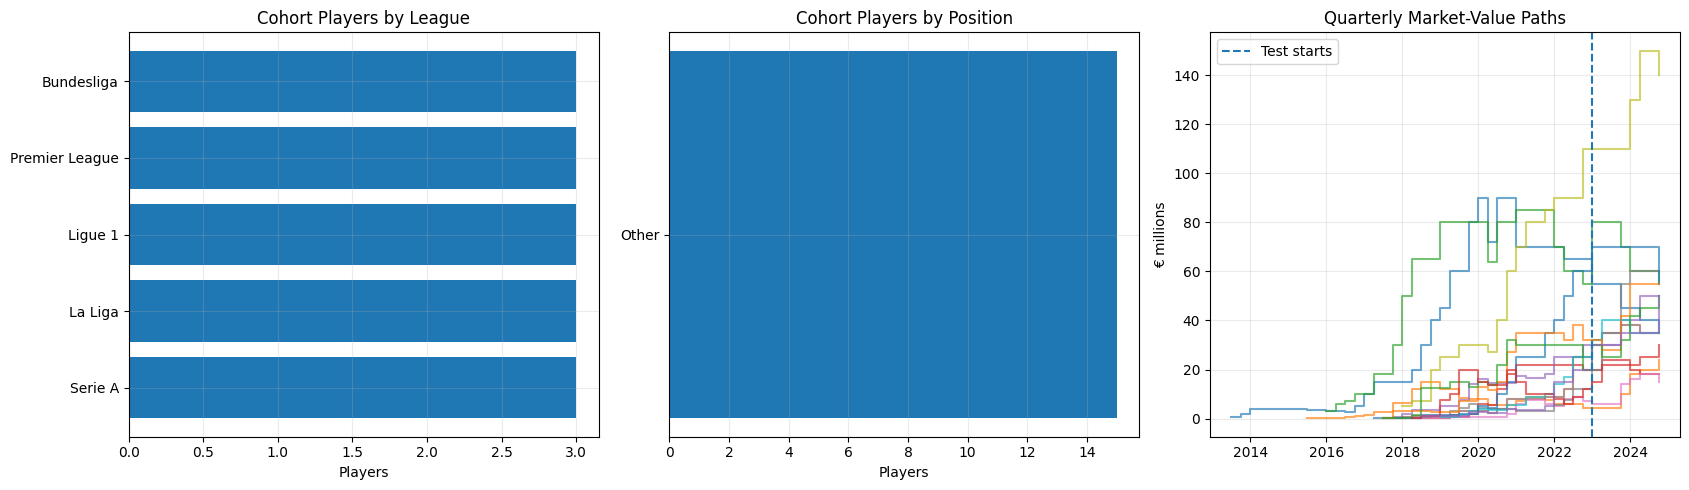

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
league_ct = cohort["league_name"].value_counts().sort_values()
axes[0].barh(league_ct.index, league_ct.values)
axes[0].set_title("Cohort Players by League"); axes[0].set_xlabel("Players")
pos_ct = cohort["position_group"].value_counts().sort_values()
axes[1].barh(pos_ct.index, pos_ct.values)
axes[1].set_title("Cohort Players by Position"); axes[1].set_xlabel("Players")
for pid, g in panel.groupby("player_id"):
    axes[2].step(g["date"], g["value_m"], where="post", alpha=.65)
axes[2].axvline(pd.Timestamp("2023-01-01"), linestyle="--", label="Test starts")
axes[2].set_title("Quarterly Market-Value Paths"); axes[2].set_ylabel("€ millions"); axes[2].legend()
for ax in axes: ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

## 3. EDA and feature evidence
We keep only the two patterns that matter most for the modeling story: the **aging curve** and **quarter-of-year / transfer-window timing**.

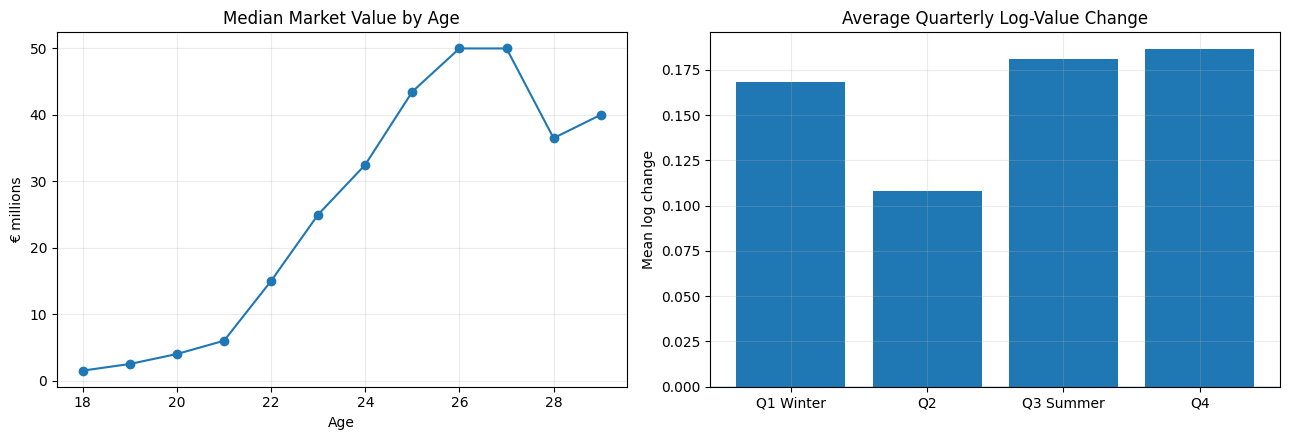

Age range: 17.3–29.3
Note: quarter effects may partly reflect Transfermarkt update timing, not transfer-price seasonality.


In [6]:
panel["age_bin"] = panel["age"].round().astype(int)
age_curve = panel.groupby("age_bin")["value_m"].agg(median="median", n="count")
age_curve = age_curve[age_curve["n"] >= 5]
panel["log_change"] = panel.groupby("player_id")["value_m"].transform(lambda s: np.log(s).diff())
season = panel.groupby("quarter_num")["log_change"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(age_curve.index, age_curve["median"], marker="o")
axes[0].set_title("Median Market Value by Age"); axes[0].set_xlabel("Age"); axes[0].set_ylabel("€ millions")
axes[1].bar(["Q1 Winter", "Q2", "Q3 Summer", "Q4"], season.values)
axes[1].axhline(0, linewidth=1); axes[1].set_title("Average Quarterly Log-Value Change")
axes[1].set_ylabel("Mean log change")
for ax in axes: ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

print("Age range:", f"{panel['age'].min():.1f}–{panel['age'].max():.1f}")
print("Note: quarter effects may partly reflect Transfermarkt update timing, not transfer-price seasonality.")

## 4. Forecasting design
**No leakage rule:** Model selection uses four earlier validation origins inside the pre-2023 training period. The 2023–2024 window is used only as the main out-of-sample test. Real 2025 values are an additional holdout and never change the selected model.

**Selection metric:** mean log MAE at **2 quarters (6 months)** and **4 quarters (12 months)** ahead. These are the horizons used by the decision prototype.

In [7]:
TEST_START_Q = 2023 * 4 + 1
FORECAST_ORIGIN = TEST_START_Q - 1
REPORT_H = [2, 4]
LOG_FLOOR_M = 0.1
VAL_ORIGINS = [2020*4+2, 2020*4+4, 2021*4+2, 2021*4+4]
VAL_H, MIN_TRAIN_Q = 4, 8
TEST_ORIGIN = FORECAST_ORIGIN
FINAL_EXOG = ["age", "window_winter", "window_summer"]
candidate_orders = [(1,0,0),(0,1,0),(1,1,0),(0,1,1),(1,1,1),(2,1,0),(0,1,2),(2,1,1)]
sarimax_orders = [(1,0,0),(0,1,0),(1,1,0),(0,1,1),(1,1,1)]

model_df = panel.drop(columns=["age_bin","log_change"], errors="ignore").copy()
model_df["log_value"] = np.log(model_df["value_m"])
model_df = model_df.sort_values(["player_id","q_idx"]).reset_index(drop=True)
train_df = model_df[model_df["q_idx"] < TEST_START_Q]
test_df = model_df[model_df["q_idx"] >= TEST_START_Q]
player_ids = model_df["player_id"].unique()

split_summary = pd.DataFrame({
    "Period": ["Validation origins", "Main test", "Extra holdout"],
    "Dates": ["2020Q2, 2020Q4, 2021Q2, 2021Q4", "2023Q1–2024Q4", "2025Q2 & 2025Q4"],
    "Role": ["Choose model", "Confirm out-of-sample performance", "Stress-test only; never choose model"]
})
display(split_summary)
print(f"Training rows: {len(train_df)} | Test rows: {len(test_df)} | Players: {len(player_ids)}")

,Period,Dates,Role
0,Validation origins,"2020Q2, 2020Q4, 2021Q2, 2021Q4",Choose model
1,Main test,2023Q1–2024Q4,Confirm out-of-sample performance
2,Extra holdout,2025Q2 & 2025Q4,Stress-test only; never choose model


Training rows: 335 | Test rows: 120 | Players: 15


## 5. Candidate models
The streamlined notebook keeps the candidate ideas that survived the full analysis: persistence, €-scale Holt, damped €-scale Holt, €-scale SARIMAX, pooled age drift, damped log-Holt, and three combinations. This preserves the final model-selection logic without repeating both exploratory tracks.

In [8]:
def future_rows(last_row, steps=4):
    rows=[]
    for k in range(1, steps+1):
        q=int(last_row["q_idx"])+k; qn=(q-1)%4+1
        rows.append({"player_id":last_row["player_id"], "q_idx":q, "quarter_num":qn,
                     "age":last_row["age"]+.25*k, "window_summer":int(qn==3), "window_winter":int(qn==1)})
    return pd.DataFrame(rows)

def fm_pooled_fit(rows):
    d=rows.sort_values(["player_id","q_idx"]).copy()
    d["d_log_value"]=d.groupby("player_id")["log_value"].diff()
    return smf.ols("d_log_value ~ age", data=d.dropna(subset=["d_log_value"])).fit()

def fm_holt_eur(y,h,damped):
    return np.asarray(Holt(y,damped_trend=damped,initialization_method="estimated").fit(optimized=True).forecast(h),float)

def fm_aic_arima(y,h):
    best_aic,best=np.inf,None
    for order in candidate_orders:
        try:
            fit=ARIMA(y,order=order).fit()
            if np.isfinite(fit.aic) and fit.aic<best_aic: best_aic,best=fit.aic,fit
        except Exception: pass
    if best is None: return np.repeat(y[-1],h)
    return np.asarray(best.forecast(h),float)

def fm_aic_sarimax(y,X,X_future,h):
    best_aic,best=np.inf,None
    for order in sarimax_orders:
        try:
            fit=SARIMAX(y,exog=X,order=order,seasonal_order=(0,0,0,0),
                        enforce_stationarity=False,enforce_invertibility=False).fit(disp=False)
            if np.isfinite(fit.aic) and fit.aic<best_aic: best_aic,best=fit.aic,fit
        except Exception: pass
    if best is None: return np.repeat(y[-1],h)
    return np.asarray(best.get_forecast(steps=h,exog=X_future).predicted_mean,float)

def fm_forecasts(hist_rows,future,pool):
    y=hist_rows["value_m"].to_numpy(float); ly=hist_rows["log_value"].to_numpy(float); h=len(future)
    zero_age=-pool.params["Intercept"]/pool.params["age"]
    f={"Persistence":np.repeat(y[-1],h)}
    f["Holt, € scale (Track A)"]=fm_holt_eur(y,h,False)
    f["Holt damped, € scale (combination)"]=fm_holt_eur(y,h,True)
    f["SARIMAX AIC, € scale (Track A)"]=fm_aic_sarimax(y,hist_rows[FINAL_EXOG].astype(float).values,
                                                        future[FINAL_EXOG].astype(float).values,h)
    pooled_log=ly[-1]+np.cumsum(pool.predict(future).values)
    f["Pooled age drift, log scale (Track B)"]=np.exp(pooled_log)
    f["Holt damped, log scale (Track B)"]=np.exp(ExponentialSmoothing(ly,trend="add",damped_trend=True).fit().forecast(h))
    f["Average of € Holt and pooled age drift (combination)"]=np.exp((np.log(np.maximum(f["Holt, € scale (Track A)"],LOG_FLOOR_M))+pooled_log)/2)
    q_before=int((future["age"].to_numpy()<zero_age).sum()); holt=f["Holt, € scale (Track A)"]
    f["€ Holt, trend stops at zero-growth age (combination)"]=np.array([y[-1] if q_before==0 else holt[min(k,q_before)-1] for k in range(1,h+1)])
    f["ARIMA AIC per player, log scale (combination)"]=np.exp(fm_aic_arima(ly,h))
    return f

def fm_backtest(origin,horizon):
    pool=fm_pooled_fit(model_df[model_df["q_idx"]<=origin]); rows=[]
    for pid,g in model_df.groupby("player_id"):
        hist_rows=g[g["q_idx"]<=origin]
        fut=g[(g["q_idx"]>origin)&(g["q_idx"]<=origin+horizon)]
        if len(hist_rows)<MIN_TRAIN_Q or len(fut)<horizon: continue
        for model,fc in fm_forecasts(hist_rows,fut,pool).items():
            for h,(_,r),pred in zip(range(1,horizon+1),fut.iterrows(),fc):
                rows.append({"origin":origin,"player_id":pid,"name":r["name"],"h":h,"model":model,
                             "actual_m":r["value_m"],"forecast_m":float(pred),"is_filled":r["is_filled"]})
    out=pd.DataFrame(rows)
    out["err_log"]=np.log(out["actual_m"])-np.log(out["forecast_m"].clip(lower=LOG_FLOOR_M))
    out["abs_err_log"]=out["err_log"].abs(); out["abs_err_m"]=(out["actual_m"]-out["forecast_m"]).abs()
    return out

print("Forecasting engine ready.")

Forecasting engine ready.


## 6. Validation selection and main test
**Key rule:** The final model is chosen **only** on the earlier validation origins. The 2023–2024 test result is reported afterward.

In [9]:
val_bt=pd.concat([fm_backtest(o,VAL_H) for o in VAL_ORIGINS],ignore_index=True)
test_bt=fm_backtest(TEST_ORIGIN,8)

def fm_scores(df):
    at_h=df[df["h"].isin(REPORT_H)]
    by_h=at_h.groupby(["model","h"])["abs_err_log"].mean().unstack("h")
    return pd.DataFrame({"log MAE h=2":by_h[2],"log MAE h=4":by_h[4],
                         "log MAE, avg h=2 & h=4":by_h[REPORT_H].mean(axis=1),
                         "MAE (€M), all h":df.groupby("model")["abs_err_m"].mean()})

val_scores,test_scores=fm_scores(val_bt),fm_scores(test_bt)
FINAL_MODEL=val_scores["log MAE, avg h=2 & h=4"].idxmin()
score_compare=pd.concat({"Validation":val_scores,"2023–2024 Test":test_scores},axis=1).sort_values(("Validation","log MAE, avg h=2 & h=4"))
print("Final model selected on validation only:", FINAL_MODEL)
display(score_compare.round(3))

Final model selected on validation only: Holt damped, € scale (combination)


Validation              \
                                                     log MAE h=2 log MAE h=4   
model                                                                          
Holt damped, € scale (combination)                         0.342       0.505   
SARIMAX AIC, € scale (Track A)                             0.343       0.512   
Persistence                                                0.352       0.538   
Average of € Holt and pooled age drift (combination)       0.350       0.564   
€ Holt, trend stops at zero-growth age (combination)       0.349       0.570   
Holt, € scale (Track A)                                    0.359       0.581   
Pooled age drift, log scale (Track B)                      0.371       0.599   
Holt damped, log scale (Track B)                           0.391       0.599   
ARIMA AIC per player, log scale (combination)              0.434       0.600   

                                                                             \
                                                     log MAE, avg h=2 & h=4   
model                                                                         
Holt damped, € scale (combination)                                    0.424   
SARIMAX AIC, € scale (Track A)                                        0.427   
Persistence                                                           0.445   
Average of € Holt and pooled age drift (combination)                  0.457   
€ Holt, trend stops at zero-growth age (combination)                  0.460   
Holt, € scale (Track A)                                               0.470   
Pooled age drift, log scale (Track B)                                 0.485   
Holt damped, log scale (Track B)                                      0.495   
ARIMA AIC per player, log scale (combination)                         0.517   

                                                                      \
                                                     MAE (€M), all h   
model                                                                  
Holt damped, € scale (combination)                             6.546   
SARIMAX AIC, € scale (Track A)                                 7.850   
Persistence                                                    6.721   
Average of € Holt and pooled age drift (combination)           8.460   
€ Holt, trend stops at zero-growth age (combination)           6.892   
Holt, € scale (Track A)                                        7.644   
Pooled age drift, log scale (Track B)                         10.397   
Holt damped, log scale (Track B)                              11.365   
ARIMA AIC per player, log scale (combination)                  8.434   

                                                     2023–2024 Test  \
                                                        log MAE h=2   
model                                                                 
Holt damped, € scale (combination)                            0.243   
SARIMAX AIC, € scale (Track A)                                0.256   
Persistence                                                   0.285   
Average of € Holt and pooled age drift (combination)          0.237   
€ Holt, trend stops at zero-growth age (combination)          0.234   
Holt, € scale (Track A)                                       0.243   
Pooled age drift, log scale (Track B)                         0.267   
Holt damped, log scale (Track B)                              0.320   
ARIMA AIC per player, log scale (combination)                 0.309   

                                                                  \
                                                     log MAE h=4   
model                                                              
Holt damped, € scale (combination)                         0.350   
SARIMAX AIC, € scale (Track A)                             0.366   
Persistence                                                0.470   
Average of € Holt 

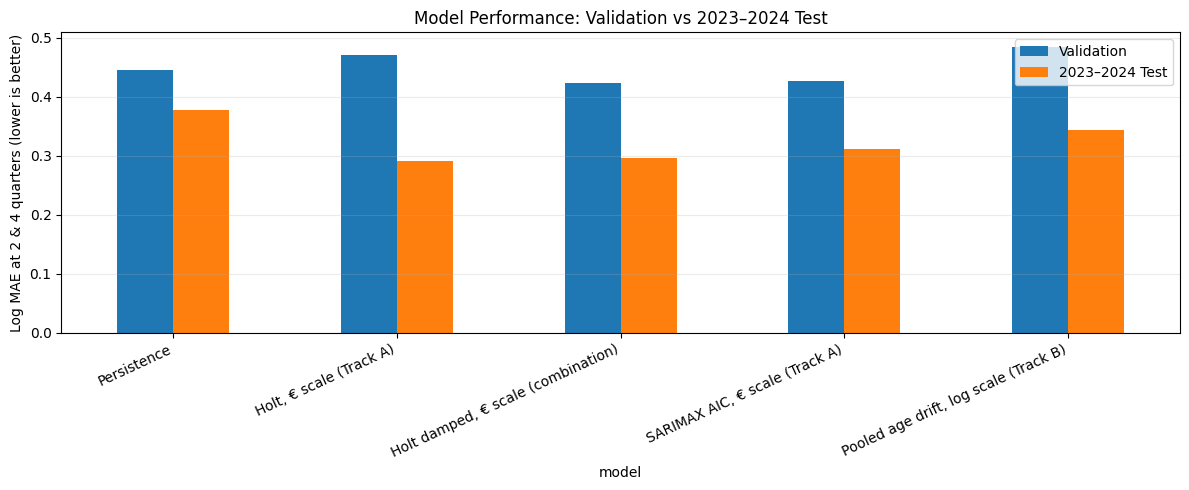

In [10]:
# PPT Figure 2 — validation vs main test for the most relevant candidates
metric="log MAE, avg h=2 & h=4"
plot_models=["Persistence","Holt, € scale (Track A)","Holt damped, € scale (combination)",
             "SARIMAX AIC, € scale (Track A)","Pooled age drift, log scale (Track B)"]
comp=pd.DataFrame({"Validation":val_scores.loc[plot_models,metric],"2023–2024 Test":test_scores.loc[plot_models,metric]})
ax=comp.plot(kind="bar",figsize=(12,5))
ax.set_ylabel("Log MAE at 2 & 4 quarters (lower is better)")
ax.set_title("Model Performance: Validation vs 2023–2024 Test")
ax.grid(axis="y",alpha=.25); plt.xticks(rotation=25,ha="right"); plt.tight_layout(); plt.show()

## 7. Uncertainty band
The final 80% interval is estimated from **validation errors**, not test errors. That keeps the 2023–2024 coverage check honest.

In [11]:
fin_val=val_bt[val_bt["model"]==FINAL_MODEL]
fin_test=test_bt[test_bt["model"]==FINAL_MODEL]
final_band=(fin_val[fin_val["h"].isin(REPORT_H)].groupby("h")["err_log"].quantile([.10,.90]).unstack())
final_band.columns=["low_err_log","high_err_log"]
rows=[]
for h in REPORT_H:
    lo,hi=final_band.loc[h]; t=fin_test[fin_test["h"]==h]
    rows.append({"Horizon":f"h={h}","Band vs forecast":f"{100*(np.exp(lo)-1):+.0f}% to {100*(np.exp(hi)-1):+.0f}%",
                 "Target coverage":"80%","2023–2024 coverage":f"{100*t['err_log'].between(lo,hi).mean():.0f}%"})
display(pd.DataFrame(rows))

,Horizon,Band vs forecast,Target coverage,2023–2024 coverage
0,h=2,-27% to +135%,80%,93%
1,h=4,-39% to +190%,80%,93%


## 8. 2025 forecasts and extra holdout
Models are refit through 2024 Q4, then evaluated on real 2025 values. **2025 does not participate in model selection.**

In [12]:
pooled_full=fm_pooled_fit(model_df)
all_2025=[]
for pid,g in model_df.groupby("player_id"):
    fut=future_rows(g.iloc[-1],steps=4).assign(name=g["name"].iloc[0])
    for model,fc in fm_forecasts(g,fut,pooled_full).items():
        for h in REPORT_H:
            all_2025.append({"player_id":pid,"name":g["name"].iloc[0],"model":model,"h":h,
                             "q_idx":int(fut["q_idx"].iloc[h-1]),"forecast_m":float(fc[h-1]),
                             "value_2024Q4_m":float(g["value_m"].iloc[-1])})
all_2025=pd.DataFrame(all_2025)

final_forecasts=all_2025[all_2025["model"]==FINAL_MODEL].copy()
final_forecasts["target_quarter"]=final_forecasts["q_idx"].map(q_label)
final_forecasts["band_low_m"]=final_forecasts.apply(lambda r:max(r["forecast_m"],LOG_FLOOR_M)*np.exp(final_band.loc[r["h"],"low_err_log"]),axis=1)
final_forecasts["band_high_m"]=final_forecasts.apply(lambda r:max(r["forecast_m"],LOG_FLOOR_M)*np.exp(final_band.loc[r["h"],"high_err_log"]),axis=1)
final_forecasts=(final_forecasts.merge(model_df.groupby("player_id")["league_name"].last(),on="player_id")
                 [["player_id","name","league_name","value_2024Q4_m","target_quarter","h","forecast_m","band_low_m","band_high_m","model"]]
                 .sort_values(["name","h"]).reset_index(drop=True))

hist_cohort=hist[hist["player_id"].isin(player_ids)].sort_values(["player_id","valuation_date"])
def value_at(pid,q):
    rows=hist_cohort[(hist_cohort["player_id"]==pid)&(hist_cohort["q_idx"]<=q)]
    return rows["value_m"].iloc[-1], bool((rows["q_idx"]==q).any())
ho=all_2025.copy()
ho[["actual_m","observed_in_quarter"]]=ho.apply(lambda r:pd.Series(value_at(r["player_id"],r["q_idx"])),axis=1)
ho["abs_err_log"]=(np.log(ho["actual_m"])-np.log(ho["forecast_m"].clip(lower=LOG_FLOOR_M))).abs()
ho["abs_err_m"]=(ho["actual_m"]-ho["forecast_m"]).abs()
holdout_scores=ho.pivot_table(index="model",columns="h",values="abs_err_log",aggfunc="mean")
holdout_scores["log MAE, avg h=2 & h=4"]=holdout_scores[REPORT_H].mean(axis=1)
holdout_scores["MAE (€M), avg"]=ho.groupby("model")["abs_err_m"].mean()
holdout_scores=holdout_scores.sort_values("log MAE, avg h=2 & h=4")

fin_ho=ho[ho["model"]==FINAL_MODEL].merge(final_forecasts[["player_id","h","band_low_m","band_high_m"]],on=["player_id","h"])
fin_ho["in_band"]=fin_ho["actual_m"].between(fin_ho["band_low_m"],fin_ho["band_high_m"])
print("2025 holdout scores")
display(holdout_scores.round(3))

2025 holdout scores


h,2,4,"log MAE, avg h=2 & h=4","MAE (€M), avg"
model,,,,
"Pooled age drift, log scale (Track B)",0.256,0.303,0.279,13.033
Average of € Holt and pooled age drift (combination),0.273,0.295,0.284,12.715
"ARIMA AIC per player, log scale (combination)",0.297,0.348,0.323,14.103
Persistence,0.302,0.350,0.326,13.467
"Holt, € scale (Track A)",0.300,0.353,0.327,13.803
"Holt damped, € scale (combination)",0.308,0.361,0.335,14.118
"€ Holt, trend stops at zero-growth age (combination)",0.299,0.372,0.336,14.299
"SARIMAX AIC, € scale (Track A)",0.322,0.389,0.356,15.185
"Holt damped, log scale (Track B)",0.346,0.455,0.400,18.283


### PPT Figure 3 — Performance across all three periods
This is the most useful model-comparison chart for the final presentation because it shows that model performance changes with market conditions.

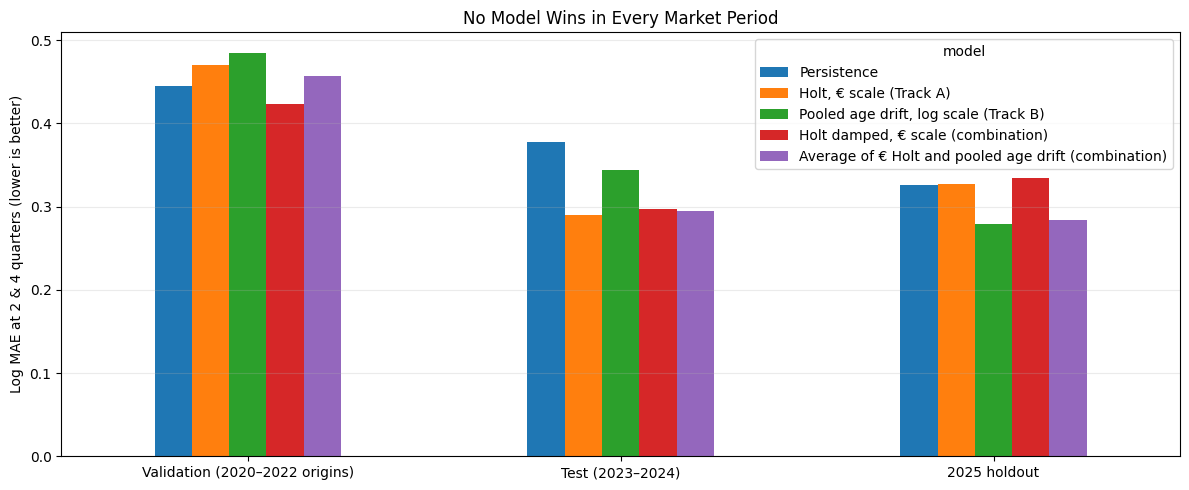

,Validation (2020–2022 origins),Test (2023–2024),2025 holdout
model,,,
Persistence,0.445,0.377,0.326
"Holt, € scale (Track A)",0.470,0.290,0.327
"Pooled age drift, log scale (Track B)",0.485,0.344,0.279
"Holt damped, € scale (combination)",0.424,0.297,0.335
Average of € Holt and pooled age drift (combination),0.457,0.294,0.284


In [13]:
cross=pd.DataFrame({"Validation (2020–2022 origins)":val_scores["log MAE, avg h=2 & h=4"],
                    "Test (2023–2024)":test_scores["log MAE, avg h=2 & h=4"],
                    "2025 holdout":holdout_scores["log MAE, avg h=2 & h=4"]})
chart_models=["Persistence","Holt, € scale (Track A)","Pooled age drift, log scale (Track B)",
              FINAL_MODEL,"Average of € Holt and pooled age drift (combination)"]
ax=cross.loc[chart_models].T.plot(kind="bar",figsize=(12,5))
ax.set_ylabel("Log MAE at 2 & 4 quarters (lower is better)")
ax.set_title("No Model Wins in Every Market Period")
ax.grid(axis="y",alpha=.25); plt.xticks(rotation=0); plt.tight_layout(); plt.show()
display(cross.loc[chart_models].round(3))

### PPT Figure 4 — Three representative player forecasts
We show the most valuable, youngest, and oldest cohort players. Forecasts are from the final model; x-marks are the real 2025 values.

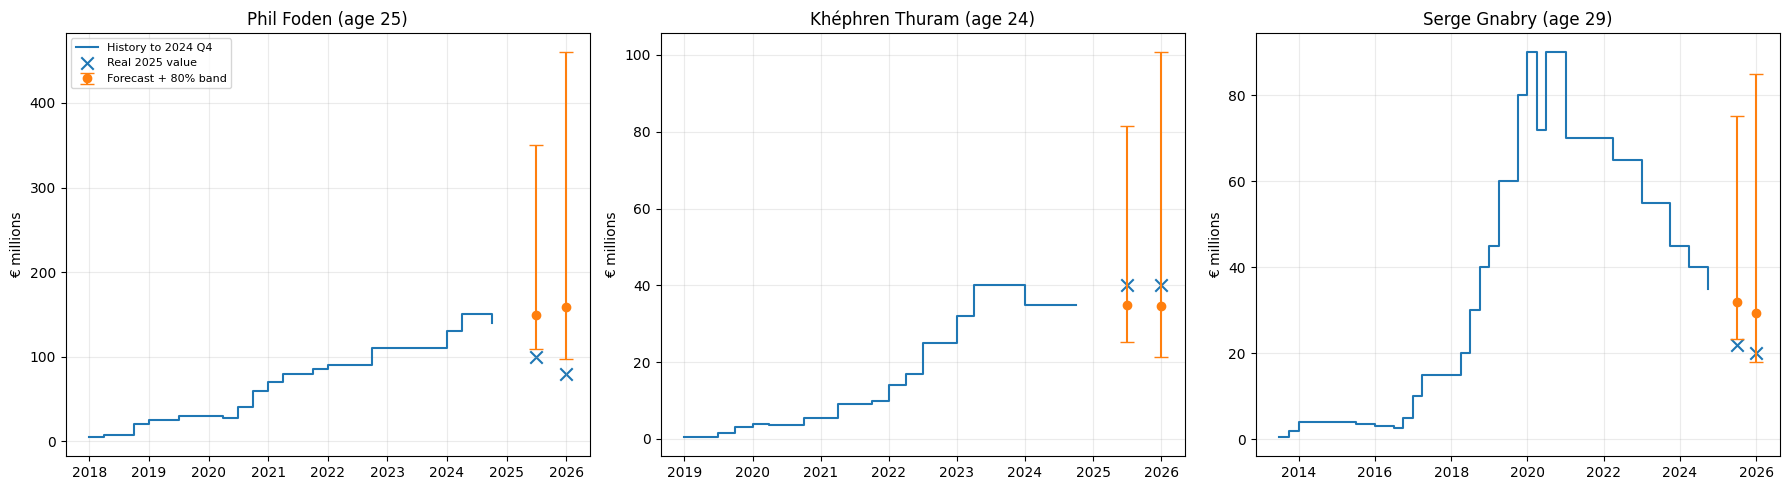

In [14]:
last_rows=model_df.groupby("player_id").tail(1).set_index("player_id")
showcase=[last_rows["value_m"].idxmax(),last_rows["age"].idxmin(),last_rows["age"].idxmax()]
fig,axes=plt.subplots(1,3,figsize=(18,5))
for ax,pid in zip(axes,showcase):
    g=model_df[model_df["player_id"]==pid]
    ax.step(g["date"],g["value_m"],where="post",label="History to 2024 Q4")
    f=final_forecasts[final_forecasts["player_id"]==pid]
    dates=pd.PeriodIndex(f["target_quarter"],freq="Q").to_timestamp(how="end")
    yerr=[f["forecast_m"]-f["band_low_m"],f["band_high_m"]-f["forecast_m"]]
    ax.errorbar(dates,f["forecast_m"],yerr=yerr,fmt="o",capsize=5,label="Forecast + 80% band")
    a=fin_ho[fin_ho["player_id"]==pid]
    adates=pd.PeriodIndex([q_label(q) for q in a["q_idx"]],freq="Q").to_timestamp(how="end")
    ax.scatter(adates,a["actual_m"],marker="x",s=80,label="Real 2025 value")
    ax.set_title(f"{g['name'].iloc[0]} (age {last_rows.loc[pid,'age']:.0f})")
    ax.set_ylabel("€ millions"); ax.grid(alpha=.25)
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

## 9. Decision-support prototype
A quoted fee above the forecast band is flagged **OVERVALUED**, inside the band **FAIR RANGE**, and below the band **UNDERVALUED**. The timing signal compares the future forecast with the player's 2024 Q4 value.

In [15]:
def final_verdict(player_name,h,quoted_fee_m):
    row=final_forecasts[(final_forecasts["name"]==player_name)&(final_forecasts["h"]==h)]
    if row.empty: raise ValueError("Use a cohort player name and h = 2 or 4.")
    r=row.iloc[0]
    if quoted_fee_m>r["band_high_m"]: verdict="OVERVALUED: fee above forecast band"
    elif quoted_fee_m<r["band_low_m"]: verdict="UNDERVALUED: fee below forecast band"
    else: verdict="FAIR RANGE: fee inside forecast band"
    timing="SELL WINDOW: value forecast to fall" if r["forecast_m"]<r["value_2024Q4_m"] else "HOLD / EXTEND: value forecast to rise or hold"
    return pd.Series({"Player":r["name"],"Target quarter":r["target_quarter"],"2024 Q4 value (€M)":r["value_2024Q4_m"],
                      "Forecast (€M)":round(r["forecast_m"],2),"80% band (€M)":f"{r['band_low_m']:.2f} to {r['band_high_m']:.2f}",
                      "Quoted fee (€M)":quoted_fee_m,"Valuation alert":verdict,"Timing signal":timing}).to_frame("Result")
example=final_forecasts.sort_values("value_2024Q4_m",ascending=False).query("h == 4").iloc[0]
display(final_verdict(example["name"],4,round(example["forecast_m"]*1.3,1)))

,Result
Player,Phil Foden
Target quarter,2025Q4
2024 Q4 value (€M),140.0
Forecast (€M),158.45
80% band (€M),96.99 to 460.14
Quoted fee (€M),206.0
Valuation alert,FAIR RANGE: fee inside forecast band
Timing signal,HOLD / EXTEND: value forecast to rise or hold


## 10. PPT key numbers and conclusions
The cell below calculates the numbers teammates should copy into the slides from the current run. This avoids manually typed results becoming stale when the notebook is rerun.

In [16]:
metric="log MAE, avg h=2 & h=4"
final_val=float(val_scores.loc[FINAL_MODEL,metric]); pers_val=float(val_scores.loc["Persistence",metric])
final_test=float(test_scores.loc[FINAL_MODEL,metric]); pers_test=float(test_scores.loc["Persistence",metric])
final_ho=float(holdout_scores.loc[FINAL_MODEL,metric]); pers_ho=float(holdout_scores.loc["Persistence",metric])

unit=test_bt[test_bt["h"].isin(REPORT_H)].groupby(["model","player_id"])["abs_err_log"].mean().unstack("model")
test_wins=int((unit[FINAL_MODEL] < unit["Persistence"]).sum())
coverage_2025=int(fin_ho["in_band"].sum())

ppt_numbers=pd.DataFrame({
    "Item":["Cohort players","Quarterly panel rows","Final model","Validation log MAE","Persistence validation log MAE",
            "2023–2024 test log MAE","Persistence test log MAE","Players beating persistence on test",
            "2025 holdout log MAE","Persistence 2025 log MAE","2025 values inside 80% band"],
    "Value":[len(player_ids),len(model_df),FINAL_MODEL,f"{final_val:.3f}",f"{pers_val:.3f}",f"{final_test:.3f}",f"{pers_test:.3f}",
             f"{test_wins} of {len(player_ids)}",f"{final_ho:.3f}",f"{pers_ho:.3f}",f"{coverage_2025} of {len(fin_ho)}"]
})
display(ppt_numbers)

# Save clean handoff tables for teammates
final_forecasts.round(2).to_csv("final_forecasts.csv",index=False)
cross.round(4).to_csv("model_comparison_three_periods.csv")
ppt_numbers.to_csv("ppt_key_numbers.csv",index=False)
print("Saved: final_forecasts.csv, model_comparison_three_periods.csv, ppt_key_numbers.csv")

,Item,Value
0,Cohort players,15
1,Quarterly panel rows,455
2,Final model,"Holt damped, € scale (combination)"
3,Validation log MAE,0.424
4,Persistence validation log MAE,0.445
5,2023–2024 test log MAE,0.297
6,Persistence test log MAE,0.377
7,Players beating persistence on test,14 of 15
8,2025 holdout log MAE,0.335
9,Persistence 2025 log MAE,0.326


Saved: final_forecasts.csv, model_comparison_three_periods.csv, ppt_key_numbers.csv


### Final takeaways for the presentation
- The final model is selected on **earlier validation origins**, before the 2023–2024 test window and before the 2025 holdout are used.
- Trend-based models can perform well in rising valuation periods, while the pooled aging curve can become more useful when values fall. **No model is best in every period.**
- The prototype is a **decision-support tool**, not a transfer-fee oracle: Transfermarkt market value is an estimate and does not include contract leverage, injuries, club urgency, brand value, or negotiation dynamics.
- The cohort is small and quality-selected, so results should not be generalized to every professional player.
- The uncertainty band is intentionally shown because point forecasts alone overstate precision.